# Notebook 1A — Data Preprocessing (Section 1)

Covers: data loading, CDR3 extraction, train/test split, liability annotation,
HIC/AC-SINS imputation.

**Output saved to Drive:**
- `df_section1.csv` — fully preprocessed clinical mAbs dataframe (input for Notebook 1B)


In [1]:
# Install required packages.
# Run this cell once. If Colab prompts to restart the runtime, do so
# and then skip back to this cell (it will already be installed).
!pip install -q ablang2        # AbLang2 antibody language model
!pip install -q torchcfm       # Conditional flow matching training loop
!pip install -q torchdiffeq    # ODE integrator for Phase 1 sampling
!pip install -q scikit-learn scipy matplotlib seaborn joblib
#!pip install -q fair-esm       # ESM2 antigen embeddings
#!pip install -q anarci         # IMGT CDR3 extraction for AbRank / SAbDab sequences
!pip install -q requests

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 105.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 109.4 MB/s eta 0:00:00


In [3]:
import os, re, warnings, json, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import spearmanr, pearsonr, ttest_rel, ks_2samp
from scipy.spatial.distance import cdist as scipy_cdist
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold
import joblib
import requests
from difflib import get_close_matches

#import esm
#from anarci import anarci as anarci_number

from torchcfm.conditional_flow_matching import ConditionalFlowMatcher
from torchdiffeq import odeint

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
torch.manual_seed(42)
np.random.seed(42)

Device: cuda


In [4]:
from google.colab import drive
drive.mount('/content/drive')

# ── Directory and file paths ──────────────────────────────────────────────────
PROJECT_DIR = '/content/drive/MyDrive/2026 Spring/BMI 702/project'
EVAL_DIR    = f'{PROJECT_DIR}/eval_inputs'
DATA_PATH   = f'{PROJECT_DIR}/GDPa1_v1.2_20250814.csv'

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(EVAL_DIR,    exist_ok=True)

CACHE = lambda name: f'{PROJECT_DIR}/{name}'

# ── Dataset column names ──────────────────────────────────────────────────────
COL_VH    = 'vh_protein_sequence'
COL_VL    = 'vl_protein_sequence'
COL_HIC   = 'HIC'
COL_SINS  = 'AC-SINS_pH7.4'
COL_FOLD  = 'hierarchical_cluster_fold'
COL_AHO_H = 'heavy_aligned_aho'
COL_AHO_L = 'light_aligned_aho'
COL_NAME  = 'antibody_name'

# ── Pipeline hyperparameters ──────────────────────────────────────────────────
TEST_FOLD       = 1
N_FLOW_SAMPLES  = 50
N_ODE_STEPS     = 100
M_SEQUENCES     = 20
TEMPERATURE     = 1.0
TOP_K_SELECT    = 5
FLOW_EPOCHS     = 1000
CURRENT_SIGMA   = 0.5
PLS_COMPONENTS  = 10
AA_VOCAB        = list('ACDEFGHIKLMNPQRSTVWY')
AA_TO_IDX       = {aa: i for i, aa in enumerate(AA_VOCAB)}
ABLANG_MASK     = '*'

# ── Binding scorer hyperparameters ────────────────────────────────────────────
SCORER_HIDDEN      = 128    # shared projection dim (CDR3 and antigen)
SCORER_HEADS       = 4      # multi-head cross-attention heads
SCORER_PRETRAIN_EP = 100    # InfoNCE pretraining epochs
SCORER_FINETUNE_EP = 50     # affinity regression fine-tuning epochs
SCORER_BATCH       = 64     # contrastive pretraining batch size
ANTIGEN_MAX_LEN    = 512    # truncate antigen sequences for ESM2
GUIDANCE_LAMBDA    = 0.5    # binding gradient scale at ODE sampling time
                             # 0 = no guidance (ablation), >1 = stronger push
ESM2_DIM           = 1280   # ESM2-650M hidden dimension

Mounted at /content/drive


In [5]:
MEAN_CACHE       = f'{EVAL_DIR}/antigen_esm2_embs.npy'
RESID_CACHE      = f'{EVAL_DIR}/antigen_esm2_resid.npy'
MASK_CACHE       = f'{EVAL_DIR}/antigen_valid_mask.npy'
RESID_PAD_CACHE  = f'{EVAL_DIR}/antigen_resid_pad_mask.npy'
SAB_MEAN_CACHE   = f'{EVAL_DIR}/sabdab_ag_embs.npy'
SAB_CDR3_CACHE   = f'{EVAL_DIR}/sabdab_cdr3_embs.npy'

---
## Section 1 — Data Loading, CDR3 Extraction & Split

### 1a — Load dataset

In [6]:
df = pd.read_csv(DATA_PATH)
print(f'Raw rows: {df.shape[0]}')

# Drop antibodies missing either chain sequence — we need both for AbLang2
df = df.dropna(subset=[COL_VH, COL_VL]).reset_index(drop=True)
print(f'After dropping missing VH/VL: {len(df)}')

print('\nPrimary oracle target missingness (will be imputed with training median):')
print(df[[COL_HIC, COL_SINS]].isna().sum())

Raw rows: 246
After dropping missing VH/VL: 246

Primary oracle target missingness (will be imputed with training median):
HIC              4
AC-SINS_pH7.4    4
dtype: int64


In [7]:
df.head()
df.columns

Index(['antibody_id', 'antibody_name', 'Titer', 'Purity', 'SEC %Monomer',
       'SMAC', 'HIC', 'HAC', 'PR_CHO', 'PR_Ova', 'AC-SINS_pH6.0',
       'AC-SINS_pH7.4', 'Tonset', 'Tm1', 'Tm2', 'hc_subtype', 'lc_subtype',
       'highest_clinical_trial_asof_feb2025', 'est_status_asof_feb2025',
       'vh_protein_sequence', 'hc_protein_sequence', 'hc_dna_sequence',
       'vl_protein_sequence', 'lc_protein_sequence', 'lc_dna_sequence',
       'hierarchical_cluster_fold', 'random_fold',
       'hierarchical_cluster_IgG_isotype_stratified_fold', 'light_aligned_aho',
       'heavy_aligned_aho'],
      dtype='object')

### 1b — HCDR3 extraction via AHo numbering

AHo CDR-H3 occupies positions 107–138 (1-indexed) = indices 106–137 (0-indexed).
The `heavy_aligned_aho` column contains the VH sequence aligned to AHo, with
dashes (`-`) for positions this antibody does not have a residue at.

We walk the aligned string and record which positions in the **ungapped** raw VH
sequence fall inside CDR3 vs framework. These integer index lists are reused
later to: (1) extract sub-embeddings, (2) place AbLang2 mask tokens, (3) splice
generated CDR3 sequences back into the parent framework.

In [8]:
AHO_CDR3_START = 106   # 0-indexed inclusive
AHO_CDR3_END   = 138   # 0-indexed exclusive (positions 106..137)

def get_cdr3_and_fw_indices(aligned_aho_seq):
    """
    Parse an AHo-aligned VH string and return two lists of integer indices
    into the UNGAPPED raw VH sequence.

    cdr3_idx : positions inside AHo CDR-H3 window (106-137)
    fw_idx   : all other positions (framework regions FR1-FR4)

    How it works: walk character by character through the aligned string.
    A dash means no residue at this AHo position for this antibody — skip it.
    Any real amino acid increments the raw-position counter and gets bucketed
    into CDR3 or framework based on its AHo position.
    """
    cdr3_idx, fw_idx = [], []
    raw_pos = 0
    for aho_pos, char in enumerate(aligned_aho_seq):
        if char == '-':
            continue
        if AHO_CDR3_START <= aho_pos < AHO_CDR3_END:
            cdr3_idx.append(raw_pos)
        else:
            fw_idx.append(raw_pos)
        raw_pos += 1
    return cdr3_idx, fw_idx

# Extract CDR3 sequences and index lists for all antibodies
hcdr3_seqs, h_cdr3_idx_list, h_fw_idx_list = [], [], []
for _, row in df.iterrows():
    if pd.isna(row[COL_AHO_H]):
        hcdr3_seqs.append(None)
        h_cdr3_idx_list.append([])
        h_fw_idx_list.append([])
        continue
    cdr3_idx, fw_idx = get_cdr3_and_fw_indices(row[COL_AHO_H])
    seq = ''.join(row[COL_VH][i] for i in cdr3_idx if i < len(row[COL_VH]))
    hcdr3_seqs.append(seq if seq else None)
    h_cdr3_idx_list.append(cdr3_idx)
    h_fw_idx_list.append(fw_idx)

df['hcdr3_sequence'] = hcdr3_seqs
df['h_cdr3_idx']     = h_cdr3_idx_list
df['h_fw_idx']       = h_fw_idx_list
df['hcdr3_len']      = df['hcdr3_sequence'].apply(
    lambda s: len(s) if isinstance(s, str) else 0)

valid = df['hcdr3_sequence'].notna() & (df['hcdr3_sequence'] != '')
print(f'Antibodies with valid HCDR3: {valid.sum()} / {len(df)}')
print(df.loc[valid, 'hcdr3_len'].describe().round(1))

Antibodies with valid HCDR3: 246 / 246
count    246.0
mean      12.5
std        3.2
min        5.0
25%       10.0
50%       12.0
75%       14.0
max       23.0
Name: hcdr3_len, dtype: float64


In [9]:
df['hcdr3_sequence']

,hcdr3_sequence
0,ARGEGNYAWFAY
1,ASFLGRGAMDY
2,ARDGTIAAMDYFDY
3,ATGSSSSWFDP
4,AKVSYLSTASSLDY
...,...
241,ARSAYYDYDGFAY
242,ARNMYTHFDS
243,ARDGITMVRGVMKDYFDY
244,ARVINWFDP


### 1c — Train/test split and CDR3 length analysis

Train (folds 2-5): 196  |  Test (fold 1): 50
CDR3 length KS test: stat=0.050  p=1.000
✓ compatible

CDR3 length distribution:
 length  train  test  train_%  test_%
      5      3     0      1.5     0.0
      6      4     0      2.0     0.0
      7      1     1      0.5     2.0
      8      8     3      4.1     6.0
      9     17     5      8.7    10.0
     10     17     5      8.7    10.0
     11     22     6     11.2    12.0
     12     35     6     17.9    12.0
     13     23     7     11.7    14.0
     14     21     8     10.7    16.0
     15     14     3      7.1     6.0
     16     10     3      5.1     6.0
     17      4     0      2.0     0.0
     18      7     1      3.6     2.0
     19      6     1      3.1     2.0
     20      1     1      0.5     2.0
     22      1     0      0.5     0.0
     23      2     0      1.0     0.0


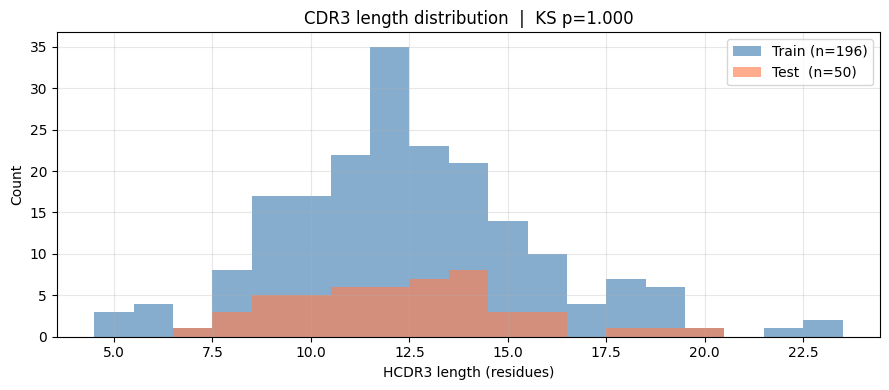

In [10]:
# Split using pre-computed hierarchical cluster folds.
# Fold 1 = test (~49 antibodies), folds 2-5 = train (~197 antibodies).
# The clustering ensures antibodies with similar sequences land in the same fold,
# so holding out fold 1 prevents the model from memorising the training sequences.
train_mask = df[COL_FOLD] != TEST_FOLD
test_mask  = df[COL_FOLD] == TEST_FOLD
train_idx  = df.index[train_mask].values
test_idx   = df.index[test_mask].values
print(f'Train (folds 2-5): {len(train_idx)}  |  Test (fold 1): {len(test_idx)}')

# ── CDR3 length distribution ──────────────────────────────────────────────────
# Important: Phase 2 places exactly len(parent_CDR3) mask tokens, so generated
# sequences are guaranteed the same length as the parent. Knowing the length
# distribution tells us whether the train/test split is balanced in this respect.
train_lens = df.loc[train_idx, 'hcdr3_len'].values
test_lens  = df.loc[test_idx,  'hcdr3_len'].values
train_lens = train_lens[train_lens > 0]
test_lens  = test_lens[test_lens > 0]

ks_stat, ks_p = ks_2samp(train_lens, test_lens)
print(f'CDR3 length KS test: stat={ks_stat:.3f}  p={ks_p:.3f}')
print('✓ compatible' if ks_p >= 0.05 else '⚠ distributions differ')

# Per-length count table
all_lens   = sorted(set(train_lens) | set(test_lens))
len_table  = pd.DataFrame({
    'length':   all_lens,
    'train':    [(train_lens == l).sum() for l in all_lens],
    'test':     [(test_lens  == l).sum() for l in all_lens],
})
len_table['train_%'] = (len_table['train'] / len(train_lens) * 100).round(1)
len_table['test_%']  = (len_table['test']  / len(test_lens)  * 100).round(1)
print('\nCDR3 length distribution:')
print(len_table[len_table[['train','test']].sum(axis=1) > 0].to_string(index=False))

# Histogram comparing train vs test length distributions
bins = np.arange(min(all_lens) - 0.5, max(all_lens) + 1.5, 1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(train_lens, bins=bins, alpha=0.65, color='steelblue',
        label=f'Train (n={len(train_lens)})')
ax.hist(test_lens,  bins=bins, alpha=0.65, color='coral',
        label=f'Test  (n={len(test_lens)})')
ax.set(xlabel='HCDR3 length (residues)', ylabel='Count',
       title=f'CDR3 length distribution  |  KS p={ks_p:.3f}')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CACHE('cdr3_length_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

### 1d — Chemical liability annotation

In [11]:
# Scan each HCDR3 for chemical degradation motifs.
# NG = deamidation, DG/DS = isomerization, NxS/NxT = N-linked glycosylation.
# These motifs are engineering liabilities in therapeutic antibodies.
# We report Spearman correlation with assay values to verify they encode
# developability signal in this dataset.
LIABILITY_PATTERNS = {
    'NG':  re.compile(r'NG'),
    'DG':  re.compile(r'DG'),
    'DS':  re.compile(r'DS'),
    'NxS': re.compile(r'N[^P]S'),
    'NxT': re.compile(r'N[^P]T'),
}

def count_liabilities(seq):
    if not isinstance(seq, str) or not seq:
        return 0, {}
    counts = {n: len(p.findall(seq)) for n, p in LIABILITY_PATTERNS.items()}
    return sum(counts.values()), counts

total_liabs, liab_details = zip(*[count_liabilities(s) for s in df['hcdr3_sequence']])
df['liability_count']  = total_liabs
df['liability_detail'] = liab_details

print('Liability count distribution:')
print(df['liability_count'].value_counts().sort_index())
for col in [COL_HIC, COL_SINS]:
    sub = df[[col, 'liability_count']].dropna()
    rho, p_val = spearmanr(sub['liability_count'], sub[col])
    print(f'Spearman ρ(liability_count, {col}): {rho:+.3f}  p={p_val:.3f}')

Liability count distribution:
liability_count
0    198
1     46
2      2
Name: count, dtype: int64
Spearman ρ(liability_count, HIC): +0.069  p=0.284
Spearman ρ(liability_count, AC-SINS_pH7.4): -0.089  p=0.166


### 1e — HIC/AC-SINS imputation and distribution check

In [12]:
# Impute the ~3 missing HIC and AC-SINS values using the TRAINING-SET median.
# Computing the median on the full dataset would leak fold-1 statistics
# into the normalization. We compute on folds 2-5 only and apply everywhere.
def impute_train_median(df, col, train_idx):
    vals   = df[col].copy().astype(float)
    median = float(np.nanmedian(vals.values[train_idx]))
    return vals.fillna(median).values, median

y_hic,  hic_med  = impute_train_median(df, COL_HIC,  train_idx)
y_sins, sins_med = impute_train_median(df, COL_SINS, train_idx)

y_hic_train,  y_hic_test  = y_hic[train_idx],  y_hic[test_idx]
y_sins_train, y_sins_test = y_sins[train_idx], y_sins[test_idx]

print(f'HIC  imputation median: {hic_med:.3f}')
print(f'SINS imputation median: {sins_med:.3f}')

# KS test: verify fold 1 distribution is not drastically different from training.
# If p < 0.05 consider using fold 2 as the test set instead.
for col, ytr, yte in [(COL_HIC, y_hic_train, y_hic_test),
                       (COL_SINS, y_sins_train, y_sins_test)]:
    s, p_val = ks_2samp(ytr, yte)
    flag = '✓' if p_val >= 0.05 else '⚠ consider fold 2'
    print(f'KS {col}: stat={s:.3f}  p={p_val:.3f}  {flag}')

HIC  imputation median: 2.735
SINS imputation median: 1.625
KS HIC: stat=0.137  p=0.400  ✓
KS AC-SINS_pH7.4: stat=0.092  p=0.853  ✓


In [13]:
# ── Save checkpoint so Notebook 1B can reload df without re-running Section 1 ──
df.to_csv(f'{PROJECT_DIR}/df_section1.csv', index=False)
print(f'Saved df_section1.csv  ({len(df)} rows)')
print('\nColumns preserved:')
print(df.columns.tolist())


Saved df_section1.csv  (246 rows)

Columns preserved:
['antibody_id', 'antibody_name', 'Titer', 'Purity', 'SEC %Monomer', 'SMAC', 'HIC', 'HAC', 'PR_CHO', 'PR_Ova', 'AC-SINS_pH6.0', 'AC-SINS_pH7.4', 'Tonset', 'Tm1', 'Tm2', 'hc_subtype', 'lc_subtype', 'highest_clinical_trial_asof_feb2025', 'est_status_asof_feb2025', 'vh_protein_sequence', 'hc_protein_sequence', 'hc_dna_sequence', 'vl_protein_sequence', 'lc_protein_sequence', 'lc_dna_sequence', 'hierarchical_cluster_fold', 'random_fold', 'hierarchical_cluster_IgG_isotype_stratified_fold', 'light_aligned_aho', 'heavy_aligned_aho', 'hcdr3_sequence', 'h_cdr3_idx', 'h_fw_idx', 'hcdr3_len', 'liability_count', 'liability_detail']
